# 1. Wczytanie bilbiotek i logów

In [1]:
from src.log_loader import load_logs
from src.audit_parser import parse_line
from config import RAW_LOG_PATH
from src.rules import run_all_rules

from src.preprocessing import detections_to_dataframe

logs = load_logs(RAW_LOG_PATH)
records = [parse_line(line) for line in logs]

print(f"Loaded {len(records)} records")

Loaded 51 records


# 2 Pierwsze 5 sparsowanych rekordów

In [2]:
for record in records[:5]:
    print(record)

LogRecord(timestamp=datetime.datetime(2024, 5, 14, 9, 20, 1, 1000), event_type='SYSCALL', user_id='1000', command='sudo', executable='/usr/bin/sudo', success=True, raw_message='type=SYSCALL msg=audit(1715671201.001:101): arch=c000003e syscall=59 success=yes exit=0 a0=55f1c2b3a2d0 a1=55f1c2b3a3f0 a2=55f1c2b3a4f0 items=2 ppid=1123 pid=1456 auid=1000 uid=1000 gid=1000 tty=pts0 ses=3 comm="sudo" exe="/usr/bin/sudo" key="priv_esc"')
LogRecord(timestamp=datetime.datetime(2024, 5, 14, 9, 20, 1, 1000), event_type='EXECVE', user_id=None, command=None, executable=None, success=None, raw_message='type=EXECVE msg=audit(1715671201.001:101): argc=3 a0="sudo" a1="cat" a2="/etc/shadow"')
LogRecord(timestamp=datetime.datetime(2024, 5, 14, 9, 20, 1, 1000), event_type='CWD', user_id=None, command=None, executable=None, success=None, raw_message='type=CWD msg=audit(1715671201.001:101): cwd="/home/lukasz"')
LogRecord(timestamp=datetime.datetime(2024, 5, 14, 9, 20, 1, 1000), event_type='PATH', user_id='0', 

# 3 Detekcja regułowa

In [3]:
from src.reporting import print_detection_results

for record in records:

    detections = run_all_rules(record)

    print_detection_results(
        record,
        detections
    )

Timestamp: 2024-05-14 09:20:01.001000
type=PATH msg=audit(1715671201.001:101): item=0 name="/usr/bin/cat" inode=123456 dev=08:01 mode=0100755 ouid=0 ogid=0 nametype=NORMAL

[ALERT] Root Activity: Root user activity detected

Timestamp: 2024-05-14 09:20:01.001000
type=PATH msg=audit(1715671201.001:101): item=1 name="/etc/shadow" inode=234567 dev=08:01 mode=0100400 ouid=0 ogid=0 nametype=NORMAL

[ALERT] Root Activity: Root user activity detected

Timestamp: 2024-05-14 09:20:02.112000
type=USER_AUTH msg=audit(1715671202.112:102): pid=1789 uid=0 auid=4294967295 ses=4294967295 msg='op=PAM:authentication acct="lukasz" exe="/usr/sbin/sshd" hostname=192.168.1.50 addr=192.168.1.50 terminal=ssh res=success'

[ALERT] Root Activity: Root user activity detected

Timestamp: 2024-05-14 09:20:02.113000
type=USER_ACCT msg=audit(1715671202.113:103): pid=1789 uid=0 auid=4294967295 ses=4294967295 msg='op=PAM:accounting acct="lukasz" exe="/usr/sbin/sshd" hostname=192.168.1.50 addr=192.168.1.50 terminal=ssh

# 4 Statystyki

In [4]:
from collections import Counter

from src.preprocessing import (
    calculate_detection_statistics
)

stats = calculate_detection_statistics(
    records
)

stats


{'total_logs': 51,
 'anomaly_logs': 23,
 'normal_logs': 28,
 'rule_counter': {'Root Activity': 11,
  'Unknown Command': 12,
  'Failed Command': 5,
  'Night Activity': 13,
  'Suspicious Command': 6}}

# 5 Dataframe

In [5]:
from src.preprocessing import (
    detections_to_dataframe
)

df = detections_to_dataframe(
    records
)

df

,timestamp,command,user_id,rule,reason
0,2024-05-14 09:20:01.001,NaN,0,Root Activity,Root user activity detected
1,2024-05-14 09:20:01.001,NaN,0,Root Activity,Root user activity detected
2,2024-05-14 09:20:02.112,NaN,0,Root Activity,Root user activity detected
3,2024-05-14 09:20:02.113,NaN,0,Root Activity,Root user activity detected
4,2024-05-14 09:20:03.221,NaN,0,Root Activity,Root user activity detected
5,2024-05-14 09:20:05.441,nginx,NaN,Unknown Command,Unknown command detected: nginx
6,2024-05-14 09:20:06.551,iptables,NaN,Unknown Command,Unknown command detected: iptables
7,2024-05-14 09:20:12.101,NaN,0,Root Activity,Root user activity detected
8,2024-05-14 09:20:12.101,NaN,0,Failed Command,Command execution failed
9,2024-05-14 09:20:13.211,su,1000,Unknown Command,Unknown command detected: su


# 6 Wykres liczby wykryć

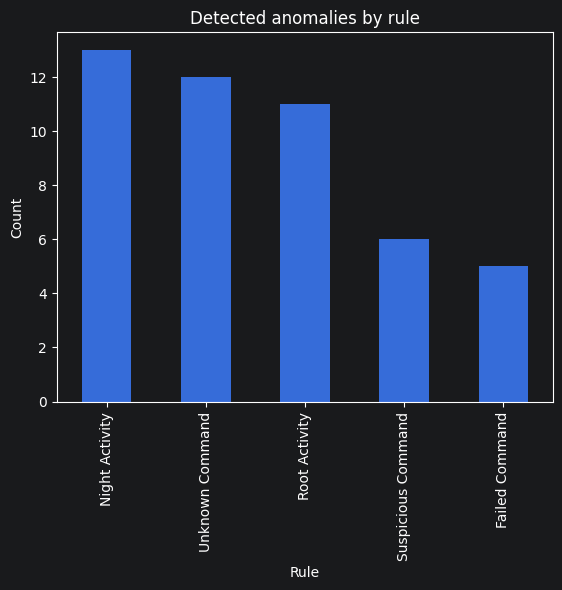

In [6]:
import matplotlib.pyplot as plt

df["rule"].value_counts().plot.bar()

plt.title("Detected anomalies by rule")
plt.xlabel("Rule")
plt.ylabel("Count")

plt.show()

# 7 Wykres kołowy

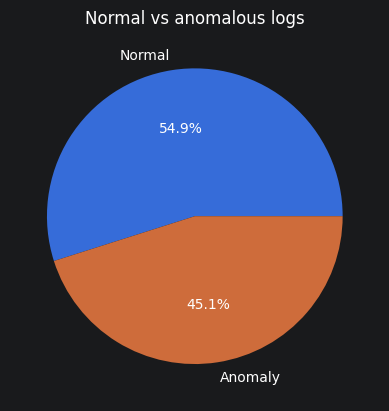

In [7]:
plt.pie(
    [
        stats["normal_logs"],
        stats["anomaly_logs"]
    ],
    labels=["Normal", "Anomaly"],
    autopct="%1.1f%%"
)

plt.title("Normal vs anomalous logs")

plt.show()

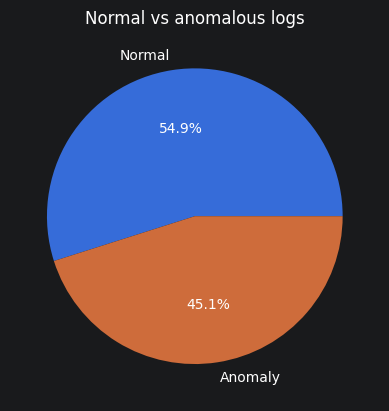

In [8]:
# Normal vs Anomaly
plt.pie(
    [stats["normal_logs"],
     stats["anomaly_logs"]],
    labels=[
        "Normal",
        "Anomaly"
    ],
    autopct="%1.1f%%"
)

plt.title(
    "Normal vs anomalous logs"
)

plt.show()

In [9]:
# SKuteczność reguły Suspicious Command
from src.preprocessing import (
    calculate_baseline_metrics
)

metrics = calculate_baseline_metrics(
    records
)

metrics

{'tp': 6,
 'fp': 0,
 'tn': 45,
 'fn': 0,
 'accuracy': 100.0,
 'precision': 100.0,
 'recall': 100.0,
 'f1': 100.0}

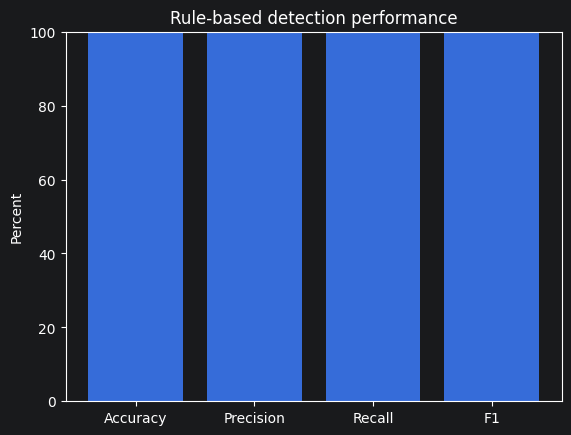

In [10]:
# Wykres skutecznośći
labels = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1"
]

values = [
    metrics["accuracy"],
    metrics["precision"],
    metrics["recall"],
    metrics["f1"]
]

plt.bar(
    labels,
    values
)

plt.ylim(0, 100)

plt.ylabel("Percent")

plt.title(
    "Rule-based detection performance"
)

plt.show()

In [11]:
# ML Forest
from src.features import (
    records_to_features
)

from src.ml_detector import (
    train_isolation_forest,
    predict_anomalies
)

df_features = records_to_features(
    records
)

model = train_isolation_forest(
    df_features
)

predictions = predict_anomalies(
    model,
    df_features
)

df_features["prediction"] = predictions

df_features.head()

,hour,is_root,success,is_night,prediction
0,9,0,1,0,1
1,9,0,0,0,1
2,9,0,0,0,1
3,9,1,0,0,1
4,9,1,0,0,1


In [12]:
# Anomalie wykryte przez Isolation Forest
df_features[
    df_features["prediction"] == -1
]

,hour,is_root,success,is_night,prediction
40,1,1,1,1,-1
46,1,1,1,1,-1


In [13]:
# Porówannie reguł i ML
rule_anomalies = stats["anomaly_logs"]

ml_anomalies = (
    df_features["prediction"] == -1
).sum()

comparison = {
    "Rule-based": rule_anomalies,
    "Isolation Forest": ml_anomalies
}

comparison

{'Rule-based': 23, 'Isolation Forest': np.int64(2)}